In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 5, 6, 7, 8, 9, 10, 
years: 2011, 2012, 2013, 2014, 2018, 2019, 2020, 2021, 


In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 
years: 


In [6]:
r_u = 0.00
near_u = 0.25
smote = 1.5
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
features_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv'

In [7]:
dataset = read_data(path, drop_columns = features_to_remove, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-01-01,αττικης,αγιας βαρβαρας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,2.4,26759.0,10925.9,44.75555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.71,NaN,14.482,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.0,0.0,0.0,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,178,0,0
1,23.82642,38.00806,2010-01-01,αττικης,αγιας παρασκευης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,7.9,62157.0,7557.5,44.85879,0.150685,0.111420,-0.013084,-0.111420,0.195709,0.144078,-0.016242,-0.144078,0.031516,0.034078,0.030554,0.034078,14.83,17.75,11.91,12.890,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.0,0.0,0.0,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,96,9,99.0,30,96,13,13,10,8,9,2,0,164,0,0
2,23.73031,37.93357,2010-01-01,αττικης,αγιου δημητριου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,5.0,71747.0,14402.8,44.74465,0.174064,0.108055,-0.070089,-0.108055,0.124195,0.074766,-0.060758,-0.074766,0.028856,0.018806,0.007160,0.018806,16.56,19.29,13.83,14.805,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.0,0.0,0.0,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,1,96,9,98.0,1,96,13,13,10,8,9,2,0,221,0,0
3,23.71341,38.04721,2010-01-01,αττικης,αγιων αναργυρων καματερου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.2,61427.0,6833.8,44.83209,0.244577,0.113856,-0.123803,-0.113856,0.252675,0.117932,-0.127495,-0.117932,0.015490,0.007317,0.005240,0.007317,15.54,18.85,12.23,12.010,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.0,0.0,0.0,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,88,9,99.0,30,88,13,13,10,8,9,2,0,190,0,0
4,23.34009,37.69503,2010-01-01,αττικης,αγκιστριου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,13.4,1107.0,85.2,44.33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.30,20.49,16.11,13.615,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,0.0,0.0,0.0,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,31,81,30,81.0,50,83,11,10,1,6,6,2,0,206,0,0


In [8]:
dataset = dataset.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2010-05-01,αττικης,αγιας βαρβαρας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,2.4,26759.0,10925.9,44.75555,0.109613,-0.012625,-0.187337,0.012625,0.138277,-0.005005,-0.207972,0.005005,0.029821,0.009216,0.029016,0.009216,23.350000,30.490000,16.210000,14.482000,8.504000,14.580000,8.572000,20.191667,11.492353,26.351538,13.455263,0.259019,3.113871,298.432541,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851,32,96,9,99.0,30,96,13,13,10,8,9,2,0,168,272,0
1,23.82642,38.00806,2010-05-01,αττικης,αγιας παρασκευης,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,7.9,62157.0,7557.5,44.85879,0.246119,0.081537,-0.195054,-0.081537,0.233828,0.069670,-0.201405,-0.069670,0.021948,0.017464,0.011308,0.017464,21.690000,27.930000,15.450000,12.890000,7.754000,15.184545,7.190000,19.492667,10.508889,24.152667,12.792500,0.726824,4.312400,321.631232,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984,32,96,9,99.0,30,96,13,13,10,8,9,2,0,105,272,0
2,23.73031,37.93357,2010-05-01,αττικης,αγιου δημητριου,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,5.0,71747.0,14402.8,44.74465,0.124847,0.005892,-0.182192,-0.005892,0.125107,0.005422,-0.183339,-0.005422,0.009420,0.007833,0.003301,0.007833,22.480000,28.450000,16.510000,14.805000,6.707143,13.976000,9.936000,21.635714,12.007500,24.690000,14.180476,0.083028,2.944309,312.558510,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627,1,96,9,98.0,1,96,13,13,10,8,9,2,0,179,412,0
3,23.71341,38.04721,2010-05-01,αττικης,αγιων αναργυρων καματερου,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,9.2,61427.0,6833.8,44.83209,0.216806,0.029374,-0.251409,-0.029374,0.229817,0.025588,-0.262820,-0.025588,0.021876,0.009936,0.015521,0.009936,23.250000,30.930000,15.570000,12.010000,7.359091,15.152000,7.963333,21.904000,10.726667,26.154000,12.920000,0.899900,5.003595,317.147450,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759,32,88,9,99.0,30,88,13,13,10,8,9,2,0,148,298,0
4,23.34009,37.69503,2010-05-01,αττικης,αγκιστριου,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,13.4,1107.0,85.2,44.33593,0.400133,0.081147,-0.245265,-0.081147,0.406088,0.079231,-0.261955,-0.079231,0.028368,0.042376,0.058683,0.042376,17.870000,20.270000,15.470000,13.615000,10.541111,12.760000,9.517273,16.742000,11.208667,18.293333,13.694211,1.681007,5.193016,291.954222,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489,31,81,30,81.0,50,83,11,10,1,6,6,2,0,125,295,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10396,23.77628,38.01477,2022-10-16,αττικης,φιλοθεης ψυχικου,16,10,41,2022,-0.101168,-0.994869,-0.866025,0.500000,-0.989040,0.147647,6.1,27400.0,4421.0,44.83787,0.128692,0.048763,-0.119247,-0.048763,0.133913,0.097384,-0.096339,-0.097384,0.066821,0.049564,0.079561,0.049564,21.450000,26.730000,16.170000,9.384667,5.348750,14.602727,6

In [10]:
dataset['lau1'].unique().shape

(66,)

In [11]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,792,0,792,7.61%
1,2011,771,30,801,7.70%
2,2012,771,44,815,7.84%
3,2013,764,35,799,7.68%
4,2014,790,2,792,7.61%
5,2015,792,0,792,7.61%
6,2016,792,0,792,7.61%
7,2017,792,0,792,7.61%
8,2018,712,138,850,8.17%
9,2019,777,23,800,7.69%


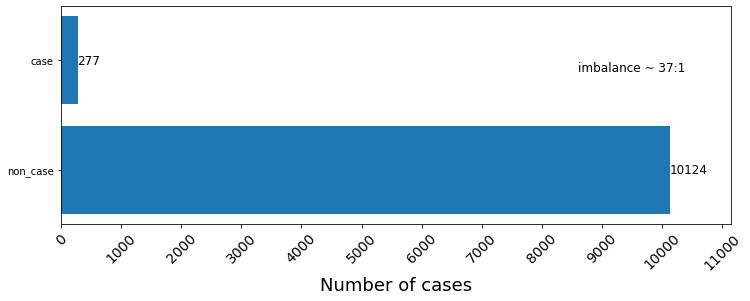

In [12]:
plot_imbalance(dataset)

In [13]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [14]:
years_to_remove = [2010, 2015, 2016, 2017, 2022]


for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    X_train.drop(columns = ['day', 'month', 'week', 'year'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df, scaler, imputer, nm, sm = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)
    w1 = w1*2

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model = train_lin_model(model, X_train, y_train)
    
    train, test, coef = predict_lin_model(trained_model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:14 || ##
Year: 2011 || w0:1, w1:14 || ##
Year: 2012 || w0:1, w1:14 || ##
Year: 2013 || w0:1, w1:14 || ##
Year: 2014 || w0:1, w1:12 || ##
Year: 2015 || w0:1, w1:14 || ##
Year: 2016 || w0:1, w1:14 || ##
Year: 2017 || w0:1, w1:14 || ##
Year: 2018 || w0:1, w1:24 || ##
Year: 2019 || w0:1, w1:14 || ##
Year: 2020 || w0:1, w1:12 || ##
Year: 2021 || w0:1, w1:12 || ##
Year: 2022 || w0:1, w1:14 || ##


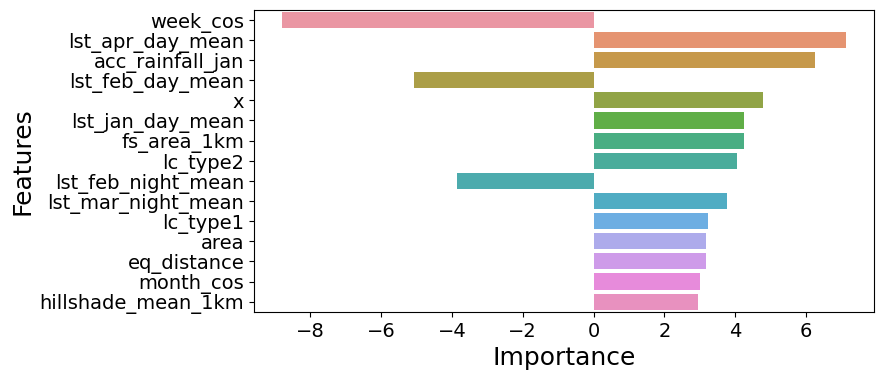

In [15]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

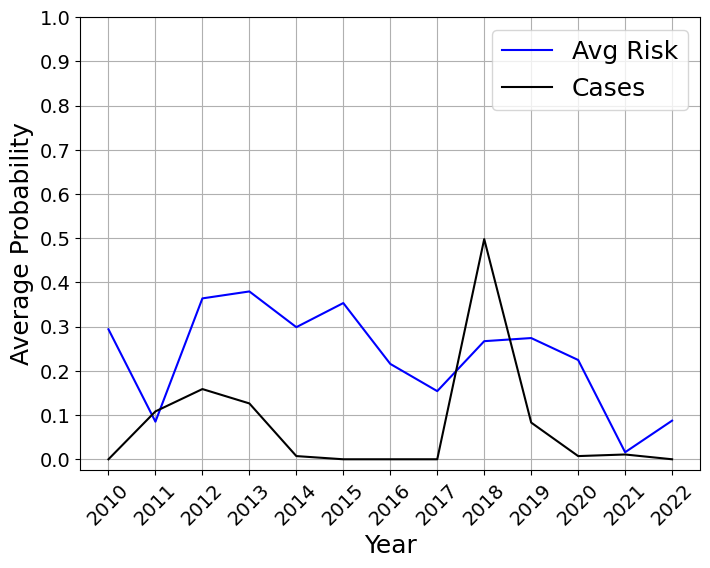

In [16]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

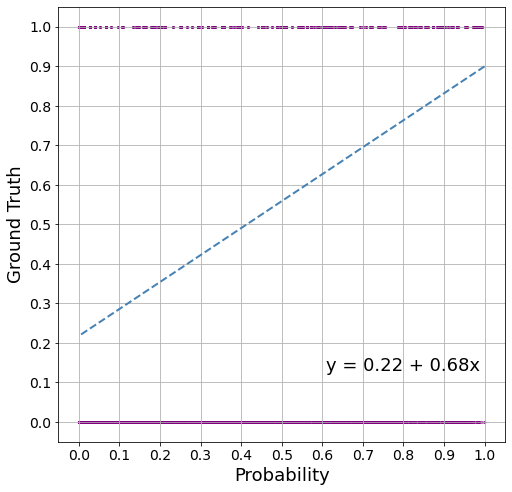

In [17]:
plot_probability_curve(results_test)

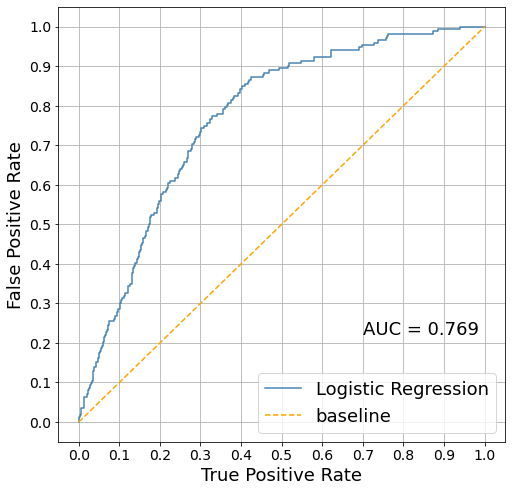

In [18]:
plot_roc_curve(results_test)

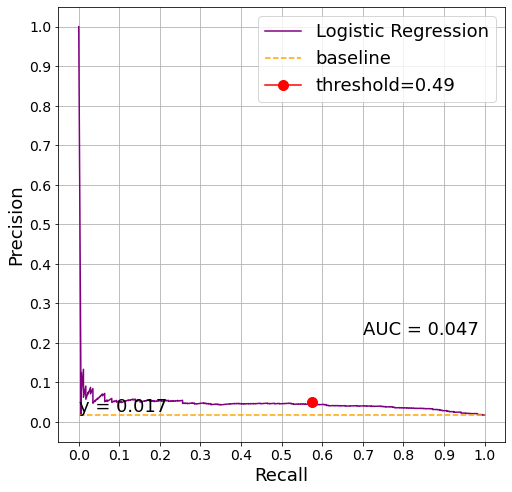

In [19]:
plot_pr_curve(results_test, plot_fbeta = True)

In [20]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 5, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 16.15%
Weighted Average: 11.63%

Random Average: 9.22%
Random Weighted Average: 12.90%


In [21]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/05/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
1,16/05/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
2,01/06/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
3,16/06/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
4,01/07/2010,0,0,0.0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
151,16/08/2022,0,0,0.0,0,NaN,NaN,NaN,NaN
152,01/09/2022,0,0,0.0,0,NaN,NaN,NaN,NaN
153,16/09/2022,0,0,0.0,0,NaN,NaN,NaN,NaN
154,01/10/2022,0,0,0.0,0,NaN,NaN,NaN,NaN


In [22]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,0,0,0.00,0,nan %,NaN,nan %,NaN
1,2011,21,8,1.71,21,38.10 %,0.3810,8.14 %,0.0814
2,2012,21,0,1.47,17,0.00 %,0.0000,8.65 %,0.0865
3,2013,28,2,2.19,23,8.70 %,0.0870,9.52 %,0.0952
4,2014,2,1,0.18,2,50.00 %,0.5000,9.00 %,0.0900
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,80,2,6.30,35,5.71 %,0.0571,18.00 %,0.1800
9,2019,15,4,1.09,15,26.67 %,0.2667,7.27 %,0.0727


In [23]:
results_test

,x,y,lau1,day,month,year,case,score
0,23.47721,37.48420,πορου,1,8,2019,0,9.998059e-01
1,23.47721,37.48420,πορου,16,8,2019,0,9.996892e-01
2,23.47721,37.48420,πορου,1,9,2019,0,9.996067e-01
3,23.47721,37.48420,πορου,16,7,2019,0,9.995741e-01
4,23.47721,37.48420,πορου,1,7,2019,0,9.991720e-01
...,...,...,...,...,...,...,...,...
10291,23.34009,37.69503,αγκιστριου,1,5,2021,0,5.333263e-08
10292,23.79175,37.96013,καισαριανης,16,5,2021,0,4.241256e-08
10293,22.98514,36.25037,κυθηρων,16,5,2021,0,2.348243e-08
10294,23.79175,37.96013,καισαριανης,1,5,2021,0,4.569455e-09


In [24]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

In [25]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,0.0000,0.4760,0.5240,0.0000,0.0000,0.0000,0.5176
1,2011,21.0000,0.1427,0.6713,0.0885,0.4762,0.3786,0.1638
2,2012,21.0000,0.5492,0.6581,0.0414,0.8571,0.3969,0.7632
3,2013,28.0000,0.5682,0.7238,0.0622,1.0000,0.5301,0.7309
4,2014,2.0000,0.4987,0.7513,0.0051,1.0000,0.0796,0.5014
5,2015,0.0000,0.5379,0.4621,0.0000,0.0000,0.0000,0.7108
6,2016,0.0000,0.3914,0.6086,0.0000,0.0000,0.0000,0.3186
7,2017,0.0000,0.2740,0.7260,0.0000,0.0000,0.0000,0.2156
8,2018,80.0000,0.4318,0.6978,0.1842,0.7875,0.6603,0.5152
9,2019,15.0000,0.4407,0.7511,0.0401,0.9333,0.4041,0.5093


In [26]:
results_test

,x,y,lau1,day,month,year,case,score
0,23.47721,37.48420,πορου,1,8,2019,0,9.998059e-01
1,23.47721,37.48420,πορου,16,8,2019,0,9.996892e-01
2,23.47721,37.48420,πορου,1,9,2019,0,9.996067e-01
3,23.47721,37.48420,πορου,16,7,2019,0,9.995741e-01
4,23.47721,37.48420,πορου,1,7,2019,0,9.991720e-01
...,...,...,...,...,...,...,...,...
10291,23.34009,37.69503,αγκιστριου,1,5,2021,0,5.333263e-08
10292,23.79175,37.96013,καισαριανης,16,5,2021,0,4.241256e-08
10293,22.98514,36.25037,κυθηρων,16,5,2021,0,2.348243e-08
10294,23.79175,37.96013,καισαριανης,1,5,2021,0,4.569455e-09


In [27]:
results_test[['x', 'y', 'day', 'month', 'year']].value_counts()

x         y         day  month  year
22.98514  36.25037  1    5      2010    1
23.78661  38.25918  1    9      2011    1
23.77839  37.94947  16   10     2018    1
                                2019    1
                                2020    1
                                       ..
23.68876  37.96117  1    5      2011    1
                                2012    1
                                2013    1
                                2014    1
24.02460  37.76124  16   10     2022    1
Length: 10296, dtype: int64

In [28]:
results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2010-2022.csv", encoding = enc, index = False)

In [29]:
scalers = {'minmax': MinMaxScaler(),
               'standard': StandardScaler(),
               'robust': RobustScaler(),
               'abs': MaxAbsScaler()}

data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
X_train.drop(columns = ['day', 'month', 'week', 'year'])
y_train = data_train['case']

if(r_u != 0):
    nan_index = []
    zero_index = []
        
    for index, row in X_train.iterrows():
        if row.isnull().values.any():
            nan_index.append(index)
            if y_train.iloc[index] == 0:
                zero_index.append(index)
            
    nan_set = set(nan_index)
    zero_set = set(zero_index)
        
    intersection = list(nan_set.intersection(zero_set))
    sampling_size = math.ceil(len(intersection) * r_u)
    removed = random.sample(intersection, sampling_size)
        
    X_train = X_train.drop(index = removed, axis = 1)
    y_train = y_train.drop(index = removed, axis = 1)

scaler = scalers.get(scaler, MinMaxScaler())
X_train = scaler.fit_transform(X_train)
    
imputer = KNNImputer()
X_train = imputer.fit_transform(X_train)

try:
    class_0_counts = y_train.value_counts()[0]
except KeyError:
    class_0_counts = 0
try:
    class_1_counts = y_train.value_counts()[1]
except KeyError:
    class_1_counts = 0

if (near_u != 0):
    nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    X_train, y_train = nm.fit_resample(X_train, y_train)

if (smote != 0):
    class_0_counts = y_train.value_counts()[0]
    sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    X_train, y_train = sm.fit_resample(X_train, y_train)

In [30]:
trained_model = train_lin_model(model, X_train, y_train)

In [31]:
trained_model

LogisticRegression(class_weight={0.0: 1, 1.0: 14}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [32]:
pickle.dump(trained_model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model.pkl', 'wb'))